In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import timedelta

In [2]:
clean_df=pd.read_csv(Path('../data/clean.csv'), parse_dates=['order_date','ship_date'])
clean_df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quantity,discount,profit,shipping_cost,order_priority,year,profit_margin,is_loss,discount_level,shipping_days
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2,0.0,106.140,35.46,Medium,2011,0.2601,0,No,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,3,0.1,36.036,9.72,Medium,2011,0.3003,0,Low,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,4,0.0,29.640,8.17,High,2011,0.4491,0,No,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,3,0.5,-26.055,4.82,High,2011,-0.5790,1,High,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,5,0.1,37.770,4.70,Medium,2011,0.3313,0,Low,7


In [9]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [13]:
order_profit = clean_df.groupby('order_id')['profit'].sum().reset_index()

In [14]:
order_profit

,order_id,profit
0,AE-2011-9160,-246.078
1,AE-2013-1130,-236.964
2,AE-2013-1530,-38.076
3,AE-2014-2840,-75.060
4,AE-2014-3830,-429.108
...,...,...
25030,ZI-2014-7160,-96.135
25031,ZI-2014-7610,-30.312
25032,ZI-2014-9540,-6.696
25033,ZI-2014-9550,-95.529


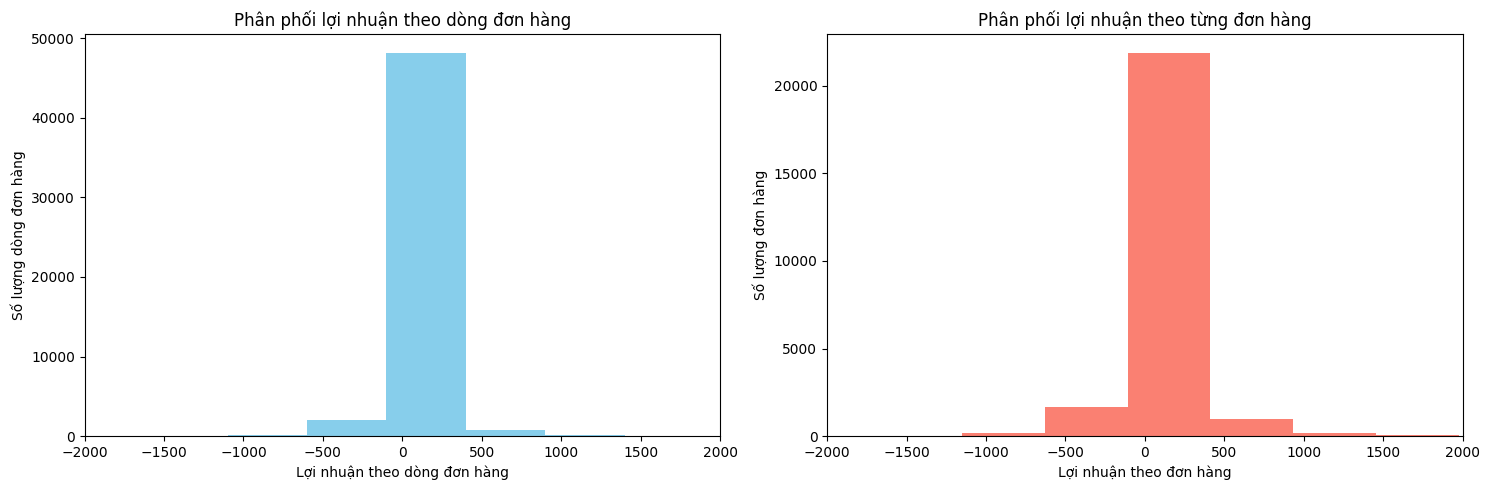

In [ ]:

fig,axes=plt.subplots(1,2,figsize=(15,5))
axes[0].hist(clean_df['profit'],bins=30,color='skyblue')
axes[0].set_title('Phân phối lợi nhuận theo dòng đơn hàng')
axes[0].set_xlabel('Lợi nhuận theo dòng đơn hàng')
axes[0].set_ylabel('Số lượng dòng đơn hàng')
axes[0].set_xlim(-2000,2000)
axes[1].hist(order_profit['profit'],bins=30,color='salmon')
axes[1].set_title('Phân phối lợi nhuận theo từng đơn hàng')
axes[1].set_xlabel('Lợi nhuận theo đơn hàng')
axes[1].set_ylabel('Số lượng đơn hàng')
axes[1].set_xlim(-2000,2000)
plt.tight_layout()
plt.show()



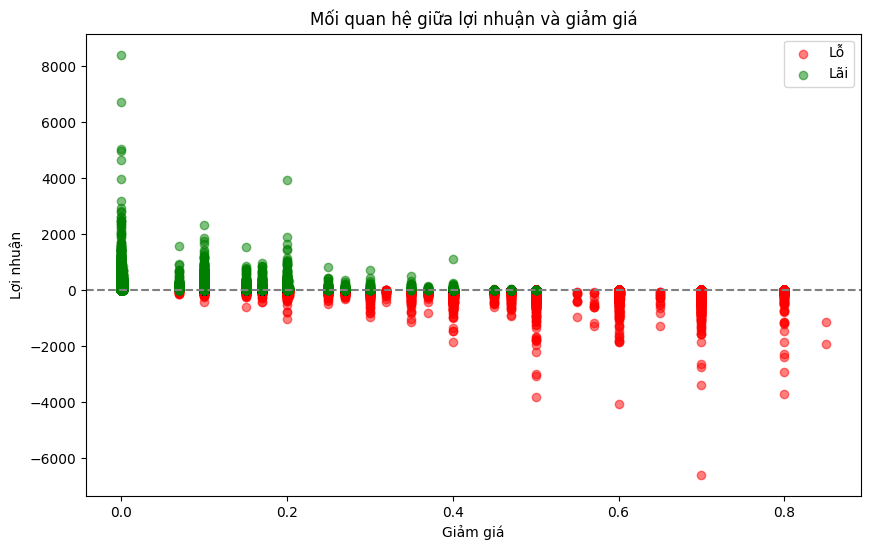

In [27]:
plt.figure(figsize=(10,6))
loss=clean_df[clean_df['profit'] < 0]
plt.scatter(loss['discount'], loss['profit'], alpha=0.5, color='red',label='Lỗ')
gain=clean_df[clean_df['profit'] >= 0]
plt.scatter(gain['discount'], gain['profit'], alpha=0.5, color='green', label='Lãi')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Mối quan hệ giữa lợi nhuận và giảm giá')
plt.xlabel('Giảm giá')
plt.ylabel('Lợi nhuận')
plt.legend()
plt.show()

In [31]:
print(clean_df.groupby('discount_level')[['profit_margin', 'is_loss']].mean())

                profit_margin   is_loss
discount_level                         
High                -0.675742  0.929079
Low                  0.156364  0.224349
Medium               0.106402  0.288946
No                   0.264827  0.000000


In [33]:
df_sub=clean_df.groupby('sub_category').agg(total_profit=('profit','sum'), total_sales=('sales','sum'), total_orders=('order_id','nunique')).reset_index()
df_sub

,sub_category,total_profit,total_sales,total_orders
0,Accessories,129626.30620,749307,2889
1,Appliances,141680.58940,1011081,1686
2,Art,57953.91090,372163,4366
3,Binders,72449.84600,461952,5392
4,Bookcases,161924.41950,1466559,2284
5,Chairs,141973.79750,1501682,3187
6,Copiers,258567.54818,1509439,2120
7,Envelopes,29601.11630,170926,2310
8,Fasteners,11525.42410,83254,2304
9,Furnishings,46967.42550,385609,2965


In [43]:
df_sub['profit_margin']=df_sub['total_profit']/df_sub['total_sales']
df_sub=df_sub.sort_values('profit_margin')
df_sub

,sub_category,total_profit,total_sales,total_orders,profit_margin
16,Tables,-64083.38870,757034,836,-0.084651
11,Machines,58867.87300,779071,1422,0.075562
15,Supplies,22583.26310,243090,2281,0.092901
5,Chairs,141973.79750,1501682,3187,0.094543
14,Storage,108461.48980,1127124,4534,0.096229
4,Bookcases,161924.41950,1466559,2284,0.110411
9,Furnishings,46967.42550,385609,2965,0.121801
13,Phones,216717.00580,1706874,3133,0.126967
8,Fasteners,11525.42410,83254,2304,0.138437
1,Appliances,141680.58940,1011081,1686,0.140128


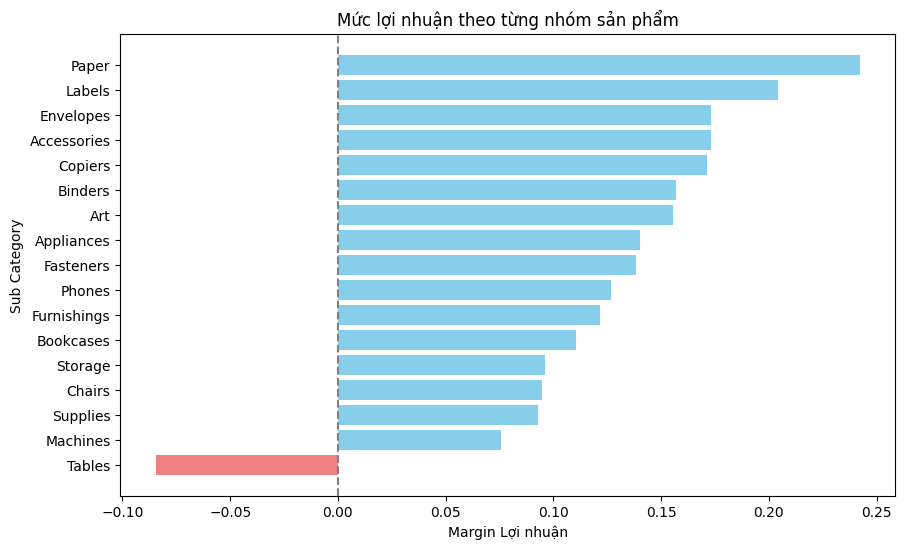

In [55]:
plt.figure(figsize=(10,6))
sub_color=['lightcoral' if margin < 0 else 'skyblue' for margin in df_sub['profit_margin']]
plt.barh(df_sub['sub_category'], df_sub['profit_margin'], color=sub_color)
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Margin Lợi nhuận')
plt.ylabel('Sub Category')
plt.title('Mức lợi nhuận theo từng nhóm sản phẩm')
plt.show()

## CUSTOMER EDA

In [73]:
df_customer_order=clean_df.groupby('customer_name')['order_id'].nunique()
df_customer_order

customer_name
Aaron Bergman         37
Aaron Hawkins         34
Aaron Smayling        31
Adam Bellavance       41
Adam Hart             42
                      ..
Xylona Preis          30
Yana Sorensen         32
Yoseph Carroll        31
Zuschuss Carroll      38
Zuschuss Donatelli    29
Name: order_id, Length: 795, dtype: int64

Text(0, 0.5, 'Số lượng khách hàng')

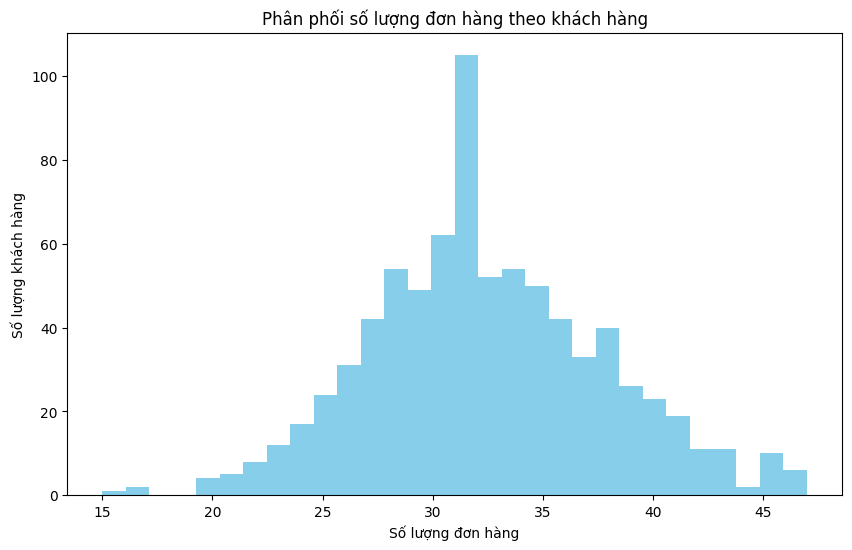

In [74]:
plt.figure(figsize=(10,6))
plt.hist(df_customer_order, bins=30, color='skyblue')
plt.title('Phân phối số lượng đơn hàng theo khách hàng')
plt.xlabel('Số lượng đơn hàng')
plt.ylabel('Số lượng khách hàng')

## RFM

In [80]:
latest_date=clean_df['order_date'].max() +timedelta(days=1)


In [112]:
rfm=clean_df.groupby('customer_name').agg(
    recency=('order_date', lambda x: (latest_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('sales', 'sum'),
    profit=('profit', 'sum')
).reset_index()

In [113]:
rfm.head()

,customer_name,recency,frequency,monetary,profit
0,Aaron Bergman,17,37,24646,4683.20800
1,Aaron Hawkins,13,34,20759,2450.92904
2,Aaron Smayling,24,31,14207,369.16180
3,Adam Bellavance,36,41,20189,4979.97690
4,Adam Hart,3,42,21720,1902.03342


In [114]:
rfm['r_score']=pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score']=pd.qcut(rfm['frequency'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score']=pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score']=rfm['r_score'] + rfm['f_score'] + rfm['m_score']

In [115]:
def rfm_segment(rfm_score):
    if rfm_score['r_score']>=4 and rfm_score['f_score']>=4 and rfm_score['m_score']>=4:
        return 'Champions'
    elif rfm_score['r_score']>=4 and rfm_score['f_score']<=2 and rfm_score['m_score']<=2:
        return 'New Customers'
    elif rfm_score['r_score']>=3 and rfm_score['f_score']>=3 and rfm_score['m_score']>=3:
        return 'Loyal Customers'
    elif rfm_score['r_score']<=2 and rfm_score['f_score']>=2:
        return 'At Risk'
    else:
        return 'Lost'

In [116]:
rfm['segment']=rfm.apply(rfm_segment, axis=1)
rfm['segment'].value_counts()

segment
Lost               285
At Risk            215
Loyal Customers    141
Champions           78
New Customers       76
Name: count, dtype: int64

In [117]:
rfm.sample(10)

,customer_name,recency,frequency,monetary,profit,r_score,f_score,m_score,rfm_score,segment
107,Brian DeCherney,50,36,10772,984.42392,1,4,1,6,At Risk
268,Erin Ashbrook,94,34,11521,868.06012,1,3,1,5,At Risk
82,Benjamin Venier,45,25,21366,2819.75040,1,1,5,7,Lost
476,Logan Haushalter,76,37,17288,1519.53100,1,4,4,9,At Risk
49,Annie Zypern,27,28,11871,924.36030,2,1,2,5,Lost
410,Justin Ellison,21,28,12910,2928.30396,3,1,2,6,Lost
636,Ritsa Hightower,8,29,17695,2002.80370,4,2,4,10,Lost
360,Jennifer Ferguson,3,34,22947,2666.84548,5,3,5,13,Loyal Customers
628,Richard Bierner,20,34,14797,-1125.65658,3,3,3,9,Loyal Customers
67,Barry Französisch,16,31,13206,940.12130,3,2,2,7,Lost


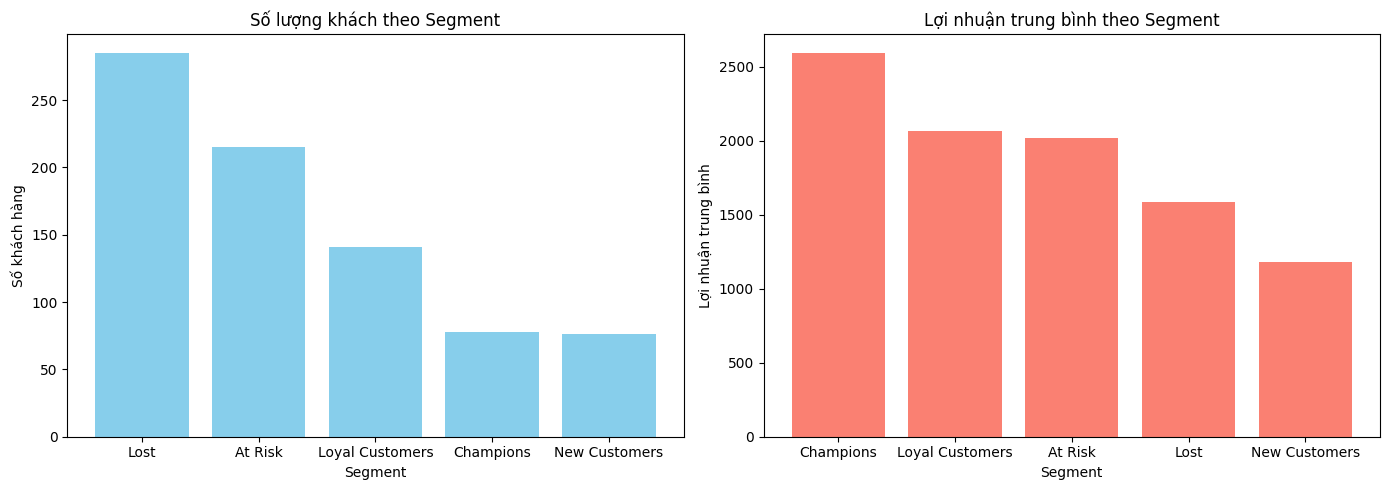

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(rfm['segment'].value_counts().index, rfm['segment'].value_counts().values, color='skyblue')
axes[0].set_title('Số lượng khách theo Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Số khách hàng')
profit_segment=rfm.groupby('segment')['profit'].mean().sort_values(ascending=False)
axes[1].bar(profit_segment.index, profit_segment.values, color='salmon')
axes[1].set_title('Lợi nhuận trung bình theo Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Lợi nhuận trung bình')
plt.tight_layout()
plt.show()